# An empirical analysis of circuit obfuscation with QUIMB

In this notebook, we will perform a few experiments on the obfuscated circuit we previously created in `pyzx_circuit_obfuscation.ipynb`. Please run the latter fully before proceeding : in particular, the files `out/obfuscated_circuit.qasm` and `out/original_circuit.qasm` should exist.

Our study will make use of the [QUIMB](https://quimb.readthedocs.io/en/latest/) library for quantum information using tensor networks.

In [50]:
import quimb.tensor as qtn
import cotengra as ctg
import matplotlib.pyplot as plt

We start by loading the original and obfuscated circuits.

Number of qubits: 10
Original and then obfuscated circuits:


(<Figure size 2250x166.667 with 1 Axes>, <Axes: >)

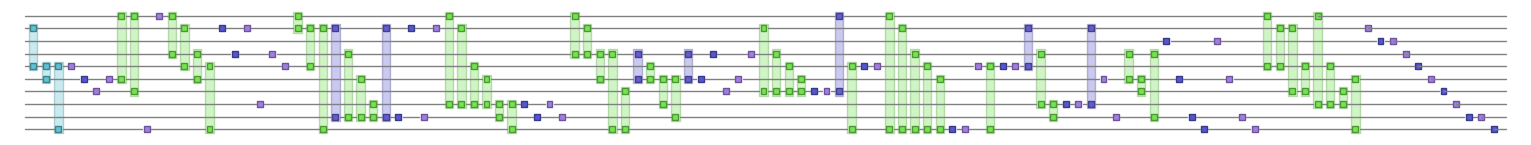

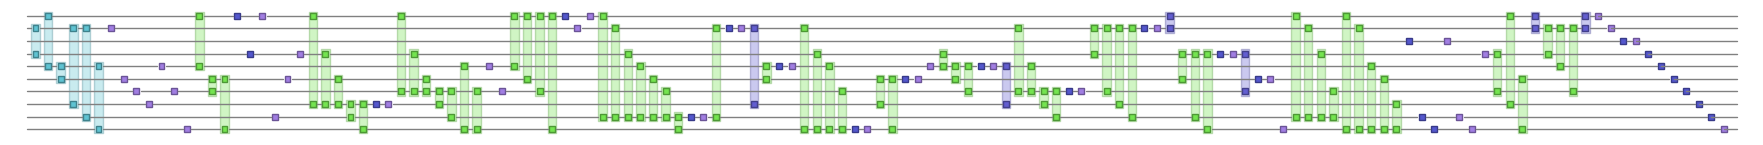

In [37]:
c_original = qtn.Circuit.from_openqasm2_file("../out/original_circuit.qasm")
c_obfuscated = qtn.Circuit.from_openqasm2_file("../out/obfuscated_circuit.qasm")

num_qubits = c_original.N
print(f"Number of qubits: {num_qubits}")

print("Original and then obfuscated circuits:")
c_original.draw()
c_obfuscated.draw()

Then, convert the circuits to tensor networks :

/home/hage/anaconda3/lib/python3.13/site-packages/quimb/tensor/circuit.py:2587: FutureWarning: In future the tensor network returned by ``circ.uni`` will not be transposed as it is currently, to match the expectation from ``U = circ.uni.to_dense()`` behaving like ``U @ psi``. You can retain this behaviour with ``circ.get_uni(transposed=True)``.
  warnings.warn(


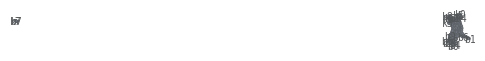

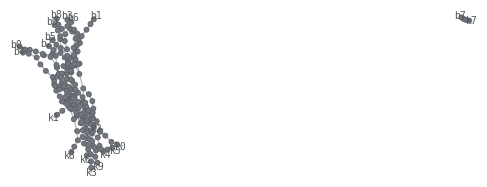

In [38]:
tn_original = c_original.uni
tn_original.draw()

tn_obfuscated = c_obfuscated.uni
tn_obfuscated.draw()

In [39]:
opt = ctg.HyperOptimizer(
    methods=["greedy", "kahypar"],
    max_repeats=32,
    parallel="threads",
    progbar=True
)

tree = tn_original.contraction_tree(opt)

cost_original = tree.total_flops(log=10)

print("FLOPs cost (log10) :", cost_original)
print("Max memory (log2)   :", tree.max_size(log=2))
print("Operations :", tree.total_cost())

F=7.61 C=8.83 S=20.00 P=20.32: 100%|██████████| 32/32 [00:35<00:00,  1.10s/it] 

FLOPs cost (log10) : 7.609501095246519
Max memory (log2)   : 20.0
Operations : 675052856


In [40]:
tree = tn_obfuscated.contraction_tree(opt)

cost_obfuscated = tree.total_flops(log=10)

print("FLOPs cost (log10) :", cost_obfuscated)
print("Max memory (log2)   :", tree.max_size(log=2))
print("Operations :", tree.total_cost())

F=7.61 C=8.83 S=20.00 P=20.32: 100%|██████████| 32/32 [00:47<00:00,  1.48s/it]

FLOPs cost (log10) : 7.609501095246519
Max memory (log2)   : 20.0
Operations : 675052856


In [41]:
# Compute the ratio of the costs
exp = cost_obfuscated - cost_original
print(f"The cost of contracting the obfuscated circuit is {10**exp:.2f} times the cost of contracting the original circuit.")

The cost of contracting the obfuscated circuit is 1.00 times the cost of contracting the original circuit.


Repeating the experience with multiple circuits, we see that there doesn't seem to be a notable difference in contracting one circuit or another. This is likely because of the calls to PyZX's `full_reduce` methods on both circuits.

In [42]:
def mps_fidelity(accurate_state, approximate_state):
    """
    Compute the fidelity between two MPS states.
    Fidelity is defined as |<accurate|approximate>|^2.
    """
    overlap = accurate_state.H @ approximate_state
    fidelity = abs(overlap)**2
    return fidelity

Step 1: Gate <Gate(label=SWAP, params=[], qubits=(6, 8))>
Entanglement entropy after step 1: 0.0
Step 2: Gate <Gate(label=SWAP, params=[], qubits=(5, 9))>
Entanglement entropy after step 2: 0.0
Step 3: Gate <Gate(label=SWAP, params=[], qubits=(4, 5))>
Entanglement entropy after step 3: 0.0
Step 4: Gate <Gate(label=SWAP, params=[], qubits=(2, 8))>
Entanglement entropy after step 4: 0.0
Step 5: Gate <Gate(label=SWAP, params=[], qubits=(1, 8))>
Entanglement entropy after step 5: 0.0
Step 6: Gate <Gate(label=SWAP, params=[], qubits=(0, 5))>
Entanglement entropy after step 6: 0.0
Step 7: Gate <Gate(label=H, params=[], qubits=(8,))>
Entanglement entropy after step 7: 0.0
Step 8: Gate <Gate(label=H, params=[], qubits=(4,))>
Entanglement entropy after step 8: 0.0
Step 9: Gate <Gate(label=H, params=[], qubits=(3,))>
Entanglement entropy after step 9: 0.0
Step 10: Gate <Gate(label=H, params=[], qubits=(2,))>
Entanglement entropy after step 10: 0.0
Step 11: Gate <Gate(label=H, params=[], qubits=(

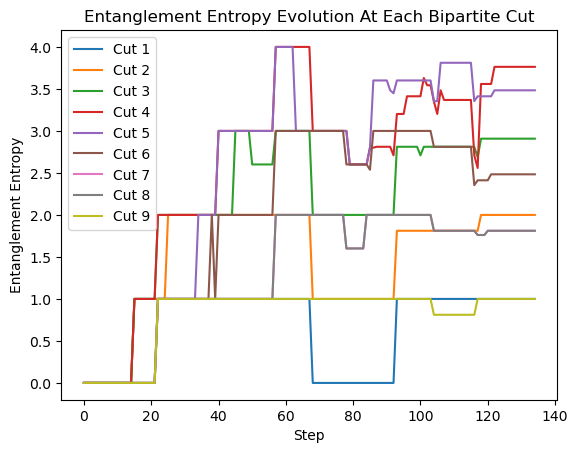

In [54]:
obfuscated_sbs = qtn.CircuitMPS(num_qubits)

entropy_list = [[] for _ in range(num_qubits)]

for step, gate in enumerate(c_obfuscated.gates):
    obfuscated_sbs.apply_gate(gate, cutoff=1e-10)

    print(f"Step {step+1}: Gate {gate}")

    psi = obfuscated_sbs.psi

    for qubit in range(1, num_qubits):
        entropy = psi.entropy(qubit)
        entropy_list[qubit].append(entropy)
    print(f"Entanglement entropy after step {step+1}: {entropy}")

for qubit in range(1, num_qubits):
    plt.plot(entropy_list[qubit], label=f'Cut {qubit}')
plt.xlabel('Step')
plt.ylabel('Entanglement Entropy')
plt.title('Entanglement Entropy Evolution At Each Bipartite Cut')
plt.legend()
plt.show()